In [8]:
import sys, os
from pathlib import Path
import pandas as pd

# Fix path resolution dynamically to point to the project root
ROOT = Path(os.getcwd()).parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from plot import (
    plot_variant_density,
    plot_af_violin,
    plot_variant_heatmap,
    plot_af_scatter
)

print(f"Project Root: {ROOT}")

Project Root: /mnt/c/IISER/SEM_8/ds_practice/genomic-variation-landscape-and-population-comparison-main/genomic-variation-landscape-and-population-comparison-main


In [9]:
# Create variables for the data and image output paths
data_path = ROOT / "data" / "processed" / "variants_filtered.parquet"
output_dir = ROOT / "outputs" / "figures"

# Load the file
df = pd.read_parquet(data_path)

print(f"Data loaded successfully! Shape: {df.shape}")
df.head()

Data loaded successfully! Shape: (37089, 16)


,chrom,pos,ref,alt,qual,filter_status,af_global,af_afr,af_eur,af_eas,af_amr,af_sas,ac,an,variant_type,source_file
0,chrY,2781758,C,T,None,PASS,0.002024,0.000000,0.000000,0.032258,0.006849,0.000000,3,1482,SNP,gnomad.genomes.v4.1.sites.chrY.vcf.bgz
1,chrY,2781761,CAAAAAAAA,C,None,PASS,0.002469,0.013158,0.000000,0.000000,0.000000,0.000000,3,1215,INDEL,gnomad.genomes.v4.1.sites.chrY.vcf.bgz
2,chrY,2782660,G,A,None,PASS,0.001632,0.001269,0.002425,0.000000,0.002979,0.000000,55,33697,SNP,gnomad.genomes.v4.1.sites.chrY.vcf.bgz
3,chrY,2782986,C,T,None,PASS,0.001306,0.000000,0.000000,0.000000,0.000000,0.030028,43,32920,SNP,gnomad.genomes.v4.1.sites.chrY.vcf.bgz
4,chrY,2783081,G,A,None,PASS,0.004827,0.003770,0.009193,0.000000,0.000294,0.000000,152,31491,SNP,gnomad.genomes.v4.1.sites.chrY.vcf.bgz


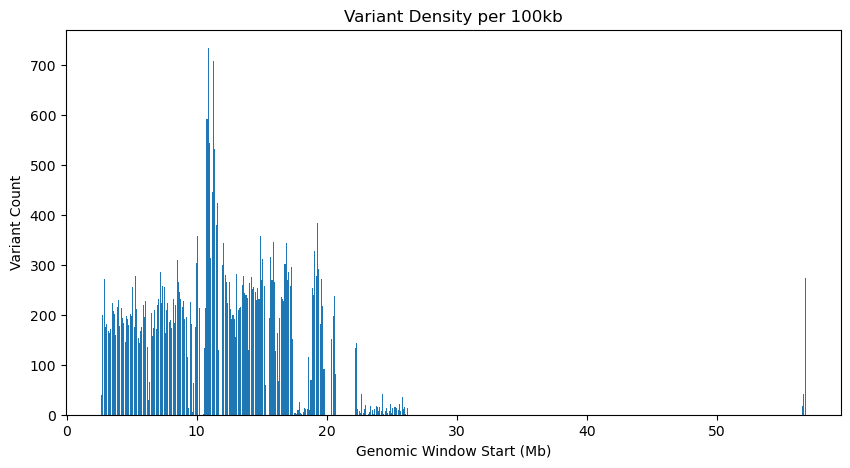

In [10]:
# 1. Variant count per 100kb genomic window
plot_variant_density(df, window_size=100_000, save=False)

/mnt/c/IISER/SEM_8/ds_practice/genomic-variation-landscape-and-population-comparison-main/genomic-variation-landscape-and-population-comparison-main/src/plot.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=melted, x="population", y="AF", ax=ax, palette="muted")


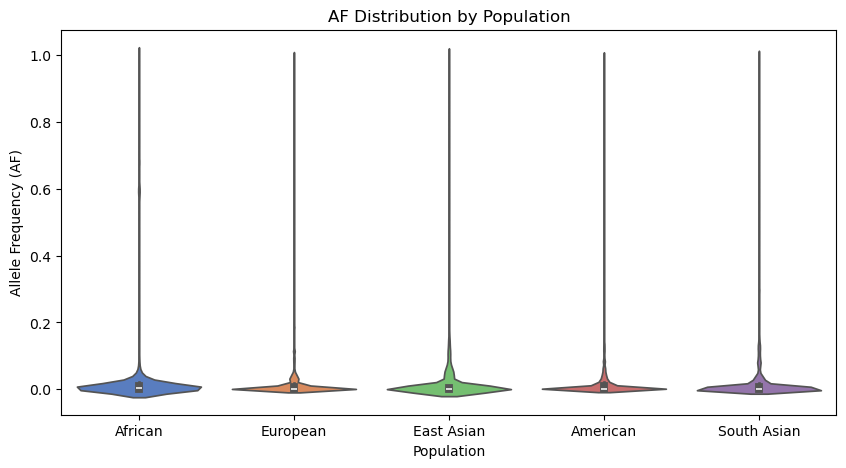

In [11]:
# 2. AF distribution by population
plot_af_violin(df, save=False)

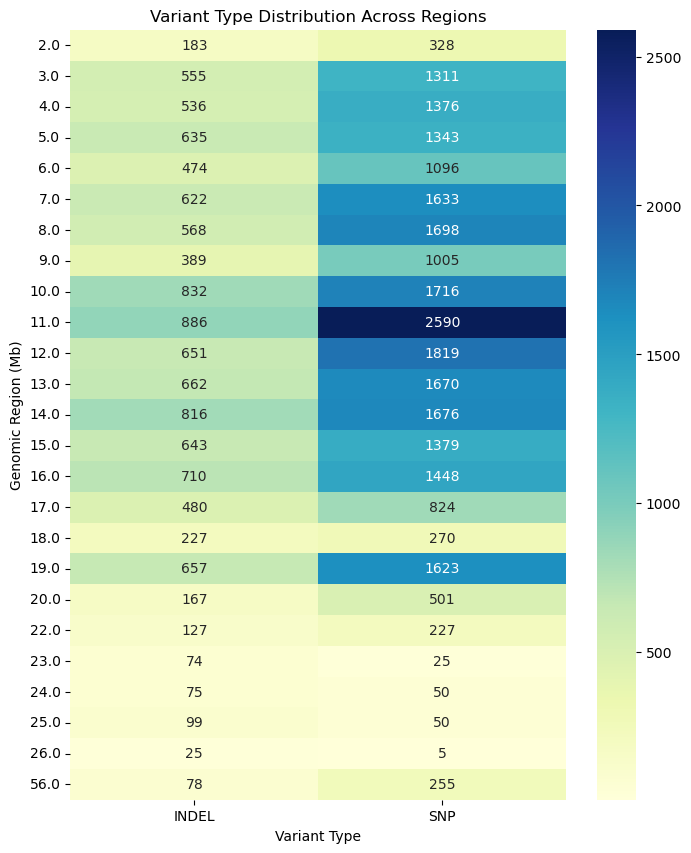

In [12]:
# 3. Variant type breakdown across genomic regions (grouped by 1 Megabase chunks)
plot_variant_heatmap(df, region_size=1_000_000, save=False)

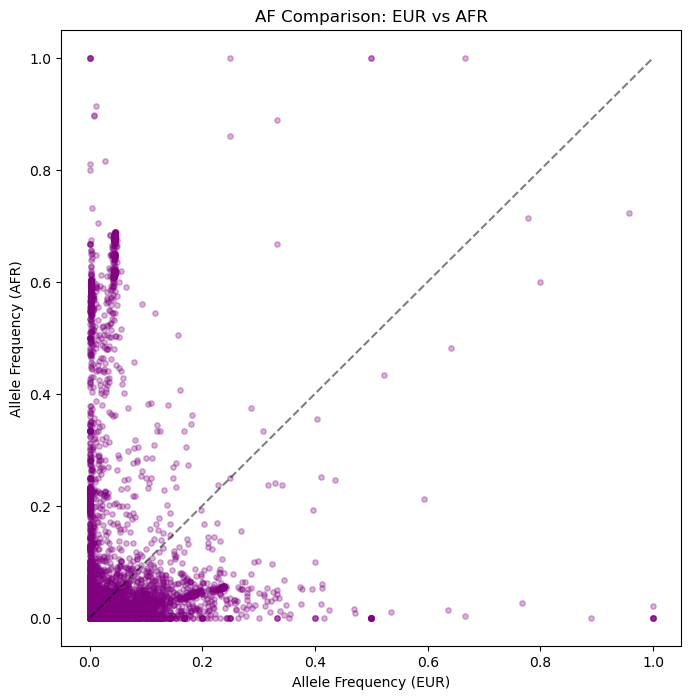

In [13]:
# 4. AF in one population vs another
plot_af_scatter(df, pop1="EUR", pop2="AFR", save=False)

In [14]:
# Save all figures to the outputs folder
plot_variant_density(df, save=True, output_dir=output_dir)
plot_af_violin(df, save=True, output_dir=output_dir)
plot_variant_heatmap(df, save=True, output_dir=output_dir)
plot_af_scatter(df, "EUR", "AFR", save=True, output_dir=output_dir)

print(f"All visualizations saved to {output_dir}")

/mnt/c/IISER/SEM_8/ds_practice/genomic-variation-landscape-and-population-comparison-main/genomic-variation-landscape-and-population-comparison-main/src/plot.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=melted, x="population", y="AF", ax=ax, palette="muted")


All visualizations saved to /mnt/c/IISER/SEM_8/ds_practice/genomic-variation-landscape-and-population-comparison-main/genomic-variation-landscape-and-population-comparison-main/outputs/figures
